In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in hbmnl_normal_experiments/ and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in hbmnl_normal_experiments/. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / BAYESM
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"folder        : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler_standard(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

folder        : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_normal_experiments
scenario=standard  K_MODEL=1  K_TRUE=1
samplers found: ['BAYESM', 'HMC', 'NUTS']


  BAYESM   mu (2, 10000, 1, 4)
  HMC      mu (2, 10000, 1, 4)
  NUTS     mu (2, 10000, 1, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' support (union over samplers); the
# True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_standard(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted support):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted support):
  Alt1       [-3.75, +5.33]
  Alt2       [-6.84, +4.92]
  Alt3       [-4.33, +6.21]
  Price      [-3.56, +6.50]


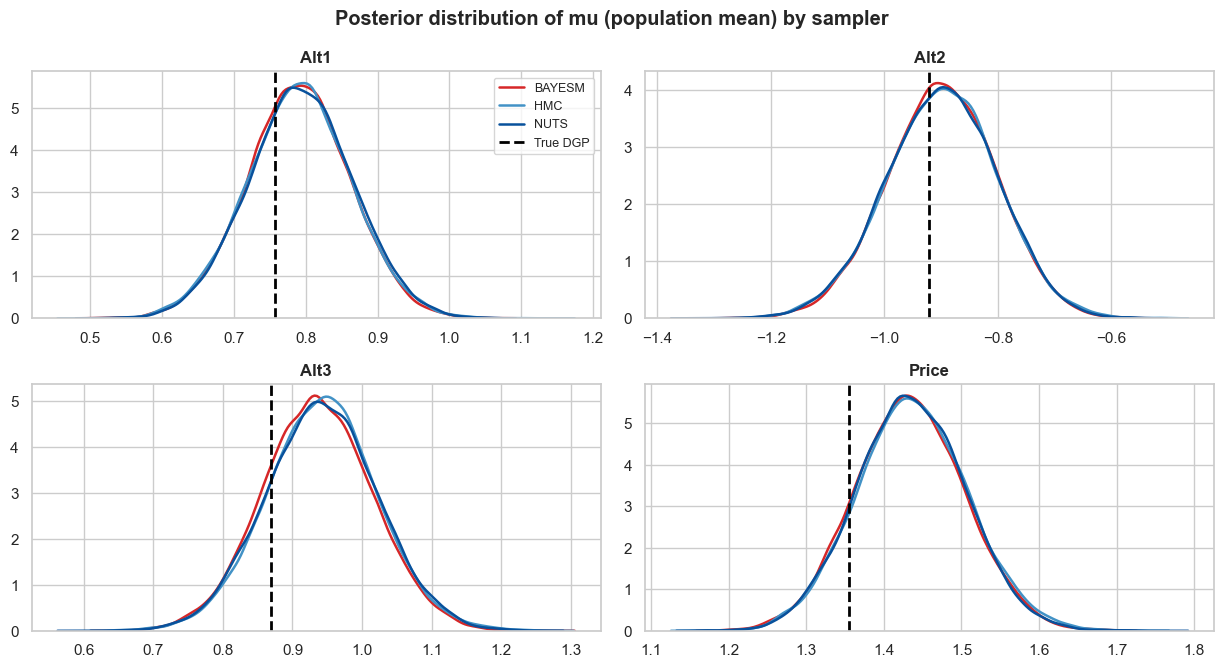

In [4]:
# ── Cell 4 : Posterior Distribution of mu, Across Samplers ──────────
# With one component there is no label-switching, so - unlike the mixture case -
# comparing samplers' posterior distributions of mu directly is meaningful, not
# just the derived density below.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "BAYESM": "#d62728"}

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for m in models:
        draws = np.asarray(m["mu"])[:, :, 0, j].reshape(-1)
        sns.kdeplot(draws, ax=ax[j], label=m["name"], color=colors.get(m["name"], "#7f7f7f"), lw=1.8)
    ax[j].axvline(true_model["mu"][0, 0, 0, j], color="black", ls="--", lw=2.0, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_ylabel("")
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Posterior distribution of mu (population mean) by sampler", fontweight="bold")
fig.tight_layout()
plt.show()

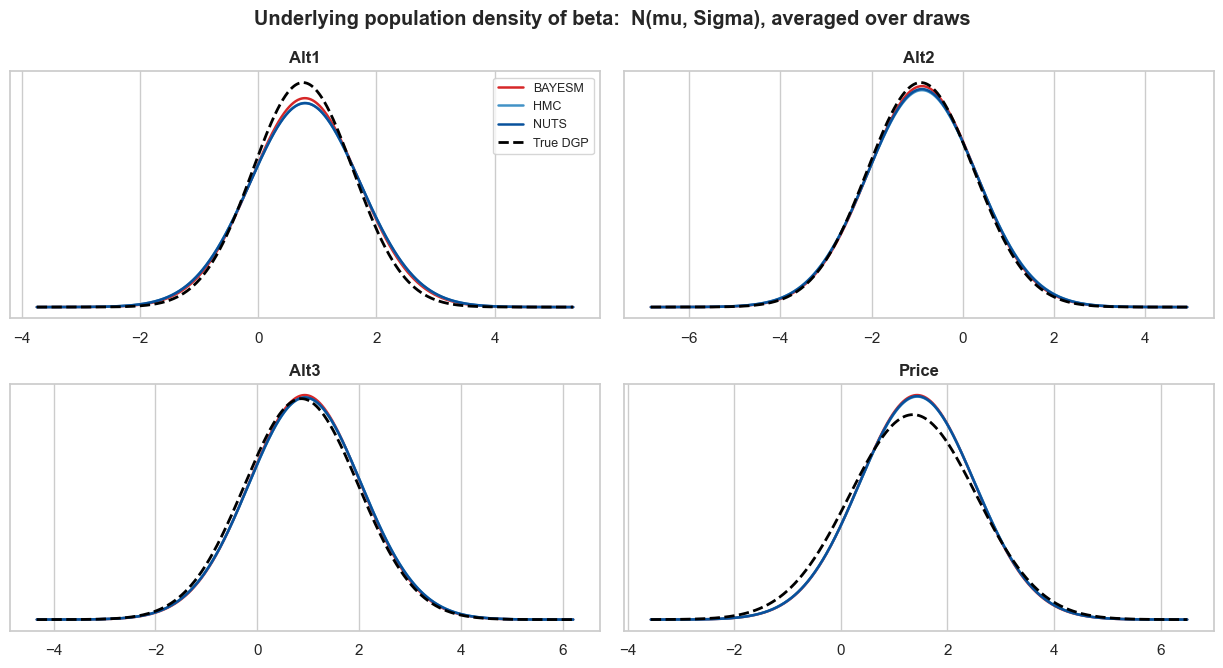

In [5]:
# ── Cell 5 : Underlying Population Density (Rossi Eq. 5.5.19, K=1) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "BAYESM": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Underlying population density of beta:  N(mu, Sigma), averaged over draws", fontweight="bold")
fig.tight_layout()
plt.show()

In [6]:
# ── Cell 6 : Density Distances vs True DGP ──────────
# Every sampler's density is compared ONLY to the True DGP density (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler param                                                    
BAYESM  Alt1     0.04190  0.00757  0.00174  0.03841       0.06141
        Alt2     0.01439  0.00086  0.00021  0.01241       0.03044
        Alt3     0.02198  0.00191  0.00048  0.02463       0.06665
        Price    0.04966  0.00932  0.00245  0.04923       0.10247
HMC     Alt1     0.05267  0.01214  0.00275  0.04903       0.07711
        Alt2     0.02215  0.00205  0.00049  0.01956       0.04323
        Alt3     0.02329  0.00218  0.00054  0.02609       0.07319
        Price    0.04732  0.00849  0.00223  0.04696       0.10048
NUTS    Alt1     0.05347  0.01253  0.00283  0.04978       0.07869
        Alt2     0.01999  0.00167  0.00040  0.01741       0.03906
        Alt3     0.02304  0.00212  0.00053  0.02584       0.07241
        Price    0.04781  0.00866  0.00228  0.04744       0.10028

In [7]:
# ── Cell 7 : Posterior Mean of mu and Sigma (Rossi Eq. 5.5.2, K=1) ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[beta]  (posterior mean of mu, averaged over draws):")
display(mean_tbl.round(3))
print("diag Var[beta]  (posterior mean of Sigma's diagonal, averaged over draws):")
display(var_tbl.round(3))

E[beta]  (posterior mean of mu, averaged over draws):


,BAYESM,HMC,NUTS,True DGP
Alt1,0.790,0.791,0.793,0.757
Alt2,-0.899,-0.899,-0.900,-0.922
Alt3,0.936,0.943,0.942,0.870
Price,1.434,1.438,1.435,1.356


diag Var[beta]  (posterior mean of Sigma's diagonal, averaged over draws):


,BAYESM,HMC,NUTS,True DGP
Alt1,0.851,0.891,0.893,0.730
Alt2,1.438,1.490,1.476,1.379
Alt3,1.227,1.256,1.252,1.259
Price,1.186,1.202,1.197,1.417


In [8]:
# ── Cell 8 : Convergence - Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the per-draw density
# N(x; mu, Sigma), over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- BAYESM ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,24,1958.563,2786.762,1.001,1.001
Alt2,24,1962.102,2812.298,1.001,1.000
Alt3,26,2487.726,3798.925,1.000,1.000
Price,26,4980.120,8012.777,1.000,1.000


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,24,497.174,757.234,1.003,1.003
Alt2,25,160.754,463.748,1.008,1.005
Alt3,26,526.787,725.130,1.006,1.005
Price,26,1126.834,1836.321,1.001,1.000


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,24,4122.855,5751.431,1.001,1.001
Alt2,25,4011.754,5319.833,1.001,1.001
Alt3,26,5863.215,7706.507,1.000,1.000
Price,26,9083.342,12517.588,1.000,1.000


In [9]:
# ── Cell 9 : Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - With one component there is no label-switching, so mu's raw posterior")
print("   (Cell 4) is already directly comparable across samplers - the density/moment")
print("   machinery below (shared with the mixture notebook - K=1 here) is an extra")
print("   cross-check, not a requirement the way it is for the mixture model.")
print(" - The grid is anchored to the fitted models' support; the True DGP is an")
print("   overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- BAYESM ---


ESS    Rhat
param moment                   
Alt1  Mean    4264.2623  1.0001
      Var     2004.8187  1.0013
Alt2  Mean    3432.9818  1.0000
      Var     2068.1599  1.0008
Alt3  Mean    6047.3404  1.0000
      Var     2635.3620  1.0005
Price Mean    8130.9309  1.0000
      Var     5659.7474  1.0001

--- HMC ---


ESS    Rhat
param moment                   
Alt1  Mean    1300.5781  1.0018
      Var      491.3956  1.0036
Alt2  Mean     970.7119  1.0015
      Var      161.2778  1.0074
Alt3  Mean    1039.2990  1.0027
      Var      544.4360  1.0060
Price Mean    1270.3732  1.0005
      Var     2007.4599  1.0004

--- NUTS ---


ESS    Rhat
param moment                    
Alt1  Mean     8600.8166  1.0006
      Var      4336.1042  1.0004
Alt2  Mean     6648.6546  1.0008
      Var      4078.9607  1.0004
Alt3  Mean     9332.3937  1.0001
      Var      6427.8037  1.0002
Price Mean    11328.3384  1.0002
      Var     11565.0215  1.0001


Notes:
 - With one component there is no label-switching, so mu's raw posterior
   (Cell 4) is already directly comparable across samplers - the density/moment
   machinery below (shared with the mixture notebook - K=1 here) is an extra
   cross-check, not a requirement the way it is for the mixture model.
 - The grid is anchored to the fitted models' support; the True DGP is an
   overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
